<a href="https://colab.research.google.com/github/BaltMart/University/blob/main/Year%202/Econometrics/Task_8_and_9_(Also_6).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

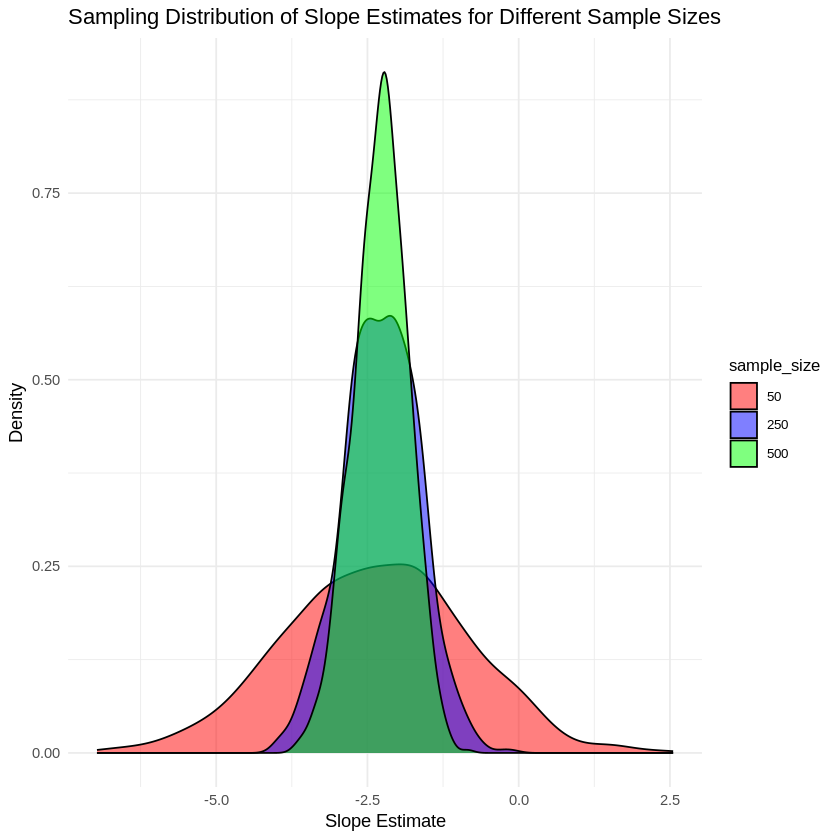

In [ ]:
library(dplyr)
library(stats)
library(ggplot2)

set.seed(2004)
mu_x = 19.64
sigma_x = 1.89
sigma_y = 19.05
beta_0 = 670
beta_1 = -2.3
var_u = sigma_y^2 - beta_1^2 * sigma_x^2
sigma_u = sqrt(var_u)


# Function to simulate data
simulate_data <- function(mu_x, sigma_x, beta_0, beta_1, sigma_u, n) {
  x = rnorm(n, mean = mu_x, sd = sigma_x)  # Generate x values
  u = rnorm(n, mean = 0, sd = sigma_u)     # Generate error term
  y = beta_0 + beta_1 * x + u              # Generate y based on linear model
  data.frame(x = x, y = y)                  # Return data as a data frame
}

M = 1000

# Sample sizes to test
sample_sizes = c(50, 250, 500)

# Initialize a list to store results
res = data.frame()

# Monte Carlo simulation loop for each sample size
for (n in sample_sizes) {
  slope_estimates = numeric(M)
  for (ii in 1:M) {
    df = simulate_data(mu_x, sigma_x, beta_0, beta_1, sigma_u, n)
    model = lm(y ~ x, data = df)  # Fit the linear model
    slope_estimates[ii] = coef(model)["x"]  # Store the slope estimate
  }
  # Add results to the data frame
  temp = data.frame(simulation = 1:M, slope_estimate = slope_estimates, sample_size = as.factor(n))
  res = rbind(res, temp)
}

# Plotting the distribution of slope estimates for each sample size
ggplot(res, aes(x = slope_estimate, fill = sample_size)) +
  geom_density(alpha = 0.5) +
  labs(title = "Sampling Distribution of Slope Estimates for Different Sample Sizes",
       x = "Slope Estimate", y = "Density") +
  theme_minimal() +
  scale_fill_manual(values = c("red", "blue", "green")) +
  theme(legend.title = element_text(size = 10), legend.text = element_text(size = 8))

ggplot(res, aes(x = slope_estimate, fill = sample_size)) +
  geom_histogram(alpha = 0.6, bins = 50, position = "identity") +
  labs(title = "Sampling Histogram of Slope Estimates for Different Sample Sizes",
       x = "Slope Estimate", y = "Number of instances") +
  theme_minimal() +
  scale_fill_manual(values = c("red", "blue", "green")) +
  theme(legend.title = element_text(size = 10), legend.text = element_text(size = 8))


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union





 A.i ----------------------


avg_earnings
<dbl>
44488.44



 A.ii ----------------------


avg_earnings
<dbl>
49987.88


...


 B.v ----------------------


[1] 0.0108753


 C ----------------------



Call:
lm(formula = earnings ~ height_cm, data = df)

Residuals:
   Min     1Q Median     3Q    Max 
-47836 -21879  -7976  34323  50599 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -512.73    3386.86  -0.151     0.88    
height_cm     278.61      19.88  14.016   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 26780 on 17868 degrees of freedom
Multiple R-squared:  0.01088,	Adjusted R-squared:  0.01082 
F-statistic: 196.5 on 1 and 17868 DF,  p-value: < 2.2e-16


,Model,Slope,Intercept,R_squared
,<chr>,<dbl>,<dbl>,<dbl>
height,Inches,707.6716,-512.733,0.0108753
height_cm,Centimeters,278.6109,-512.733,0.0108753


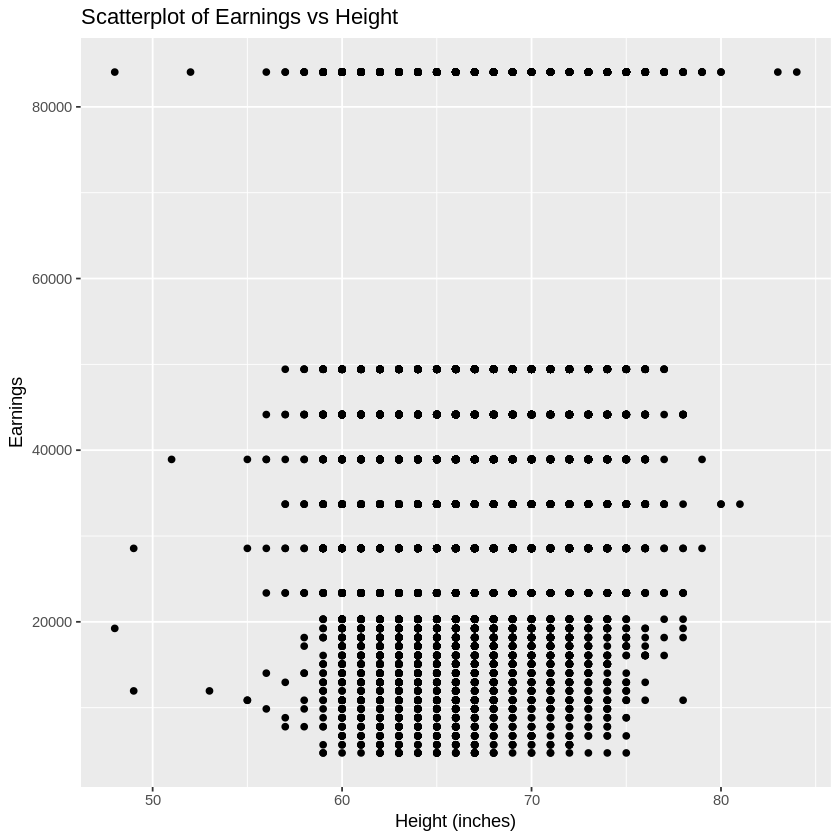

In [ ]:
library(ggplot2)
library(dplyr)
library(readr)

# Reading data
#df = read.csv("/content/Earnings_and_Height.csv", header = TRUE)
df = read.csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQ0IeTCKQ5-T9VO5CGsbgyBOHnBxAgJDyEuU0CR2NmiEsPRPiCpl2E3VhJwqA1TKg/pub?output=csv",
              header = TRUE,
              dec = ",")

#head(df) # Used only to check whether data imported correctly

cat("\n A.i ----------------------\n")
#A
#i

avg_earnings_short = df %>%
  filter(height <= 67) %>%
  summarize(avg_earnings = mean(earnings))

avg_earnings_short


cat("\n A.ii ----------------------\n")
#ii
avg_earnings_tall = df %>%
  filter(height > 67) %>%
  summarize(avg_earnings = mean(earnings))

avg_earnings_tall

cat("\n A.iii ----------------------\n")
#iii
diff_earnings = avg_earnings_tall$avg_earnings - avg_earnings_short$avg_earnings
round(diff_earnings, 0)

cat("\n A.iv ----------------------\n")
#iv

# New variable `is_tall`
df$is_tall = ifelse(df$height > 67, 1, 0)

# Run a regression of earnings on is_tall
model = lm(earnings ~ is_tall, data = df)

# Summary of the model
summary(model)

# Confidence interval for the difference in earnings
confint(model, level = 0.95)


cat("\n B.i ----------------------\n")
#B
#i
# Scatterplot of earnings vs height
ggplot(df, aes(x = height, y = earnings)) +
  geom_point() +
  labs(title = "Scatterplot of Earnings vs Height", x = "Height (inches)", y = "Earnings")

cat("\n B.ii ----------------------\n")
#ii
model_height = lm(earnings ~ height, data = df)
summary(model_height)

cat("\n B.iii ----------------------\n")
# iii
predicted_earnings = predict(model_height,
                              newdata = data.frame(height = c(65, 67, 70)))
round(predicted_earnings, 2)

cat("\n B.iv ----------------------\n")
#iv
pf(summary(model_height)$fstatistic[1],
  summary(model_height)$fstatistic[2],
  summary(model_height)$fstatistic[3],
  lower.tail=F)


cat("\n B.v ----------------------\n")
#v
summary(model_height)$r.squared

cat("\n C ----------------------\n")
#C

df$height_cm = df$height * 2.54
model_cm = lm(earnings ~ height_cm, data = df)

summary(model_cm)

# Slope and intercept of the original model (in inches)
slope_inches = coef(model_height)["height"]
intercept_inches = coef(model_height)["(Intercept)"]
r_squared_inches = summary(model_height)$r.squared

# Slope and intercept of the new model (in cm)
slope_cm = coef(model_cm)["height_cm"]
intercept_cm = coef(model_cm)["(Intercept)"]
r_squared_cm = summary(model_cm)$r.squared

# Compare the two models
comparison = data.frame(
  Model = c("Inches", "Centimeters"),
  Slope = c(slope_inches, slope_cm),
  Intercept = c(intercept_inches, intercept_cm),
  R_squared = c(r_squared_inches, r_squared_cm)
)

comparison


Problem Set 2
TASK 6

a) If this causal mechanism as described above is correct, the omited variable cognitive ability is correlated with hight as nutrition while developing has impact on both. When this variable is hidden, the seeming effect of X on Y seems to be higher than it is in reality or when controlled for omited variables. This means that the estimated slope is too large as the omited variable leads us to overestimate the effect of Height on Earnings.

b)

In [ ]:
# New dummy variables decribing years of education

df$lt_hs = ifelse(df$educ < 12, 1, 0)

df$hs = ifelse(df$educ == 12, 1, 0)

df$some_col = ifelse(df$educ > 12 & df$educ < 16, 1, 0)

df$college = ifelse(df$educ >= 16, 1, 0)

c)

In [ ]:
# i)
model2 = lm(formula = earnings ~ height + lt_hs + hs + some_col, data = filter(df, sex == 0))
summary(model2)


Call:
lm(formula = earnings ~ height + lt_hs + hs + some_col, data = filter(df, 
    sex == 0))

Residuals:
   Min     1Q Median     3Q    Max 
-54537 -19082  -5808  24386  58676 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  50749.52    6013.68   8.439   <2e-16 ***
height         135.14      92.55   1.460    0.144    
lt_hs       -31857.81     963.77 -33.055   <2e-16 ***
hs          -20417.89     626.18 -32.607   <2e-16 ***
some_col    -12649.07     685.30 -18.458   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 24920 on 9969 degrees of freedom
Multiple R-squared:  0.1382,	Adjusted R-squared:  0.1378 
F-statistic: 399.6 on 4 and 9969 DF,  p-value: < 2.2e-16


The positive effect of height reduces considerably after controlling for education

In [ ]:
# ii)
# Constructing intervals
confint(model2, "height", level = 0.95)
confint(model2, "height", level = 0.99)
model2_summary = summary(model2)

# Extracting and printing P-value to see if we can reject the null
p_value_height = model2_summary$coefficients["height", "Pr(>|t|)"]
print(paste("P-value:", p_value_height))

,2.5 %,97.5 %
height,-46.26748,316.5517


,0.5 %,99.5 %
height,-103.2872,373.5714


[1] "P-value: 0.144249131062239"


From this p-value we cannot reject the null from either of the confidence intervals.

iii)
My findings are consistent with the "cognitive ability as the omitted variable" mechanism outlined above because after controlling for education level the effect of height on estimated earnings became statistically insignifcant, meaning that the omitted variable inflated the effect of height on earnings.

iv) The interpretation of our intercept would be that a person of 0 height and with at least 16 years of education is expected to earn 50749. In reality, however, a person isn't going to be of zero height, so intercept plus effect of height would be the expected to be the earnings of college educated person given their height.

In [ ]:
# v
# Extracting p-values of each education level
p_value_lt_hs = model2_summary$coefficients["lt_hs", "Pr(>|t|)"]
p_value_hs = model2_summary$coefficients["hs", "Pr(>|t|)"]
p_value_some_col = model2_summary$coefficients["some_col", "Pr(>|t|)"]

# Printing out results
print(paste("P-value of less than a high school diploma:", p_value_lt_hs))
print(paste("P-value of a high school diploma:", p_value_hs))
print(paste("P-value of some college:", p_value_some_col))


[1] "P-value of less than a high school diploma: 1.82826444387575e-227"
[1] "P-value of a high school diploma: 1.09226493888308e-221"
[1] "P-value of some college: 7.92061223707202e-75"


Estimated coefficients are statistically significant. The economic interpretation would be that increasing time spent in education (up to 16 years) increased earnings outcomes.

In [ ]:
# vi
predicted_earn_of_hs_w = predict(model2,
                                newdata = data.frame(height = 65,
                                                hs = 1,
                                                lt_hs = 0,
                                                some_col = 0))
print(paste("Predicted earnings for a woman who has a high-school diploma and is 65 inches tall",
            round(predicted_earn_of_hs_w, 2)))

[1] "Predicted earnings for a woman who has a high-school diploma and is 65 inches tall 39115.87"


vii) For heights effects on earnings we can probably say, that it does not have a real significant causal effect on earnings, but we cannot say definitively, that the included new variables provide causal relationships. Even though the R^2 increased with our new regression, we cannot say, that these regressors are a true cause of changes in earnings.

viii) My current regression does not include "college" because including it would violate "dummy-variable trap" becoming a linearly dependent group of variable which we could not estimate with OLS.

If we wanted to include college, we could, but then we would have to change the way the define the regression set up.



In [ ]:
# ix

model3 = lm(formula = earnings ~ height + hs + some_col + college, data = filter(df, sex == 0))
summary(model3)

install.packages("modelsummary")
library(modelsummary)
modelsummary(list("Model 2" = model2, "Model 3" = model3),
             title = "Comparison of Regression Models")


Call:
lm(formula = earnings ~ height + hs + some_col + college, data = filter(df, 
    sex == 0))

Residuals:
   Min     1Q Median     3Q    Max 
-54537 -19082  -5808  24386  58676 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 18891.71    5952.00   3.174  0.00151 ** 
height        135.14      92.55   1.460  0.14425    
hs          11439.92     927.55  12.334  < 2e-16 ***
some_col    19208.74     971.36  19.775  < 2e-16 ***
college     31857.81     963.77  33.055  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 24920 on 9969 degrees of freedom
Multiple R-squared:  0.1382,	Adjusted R-squared:  0.1378 
F-statistic: 399.6 on 4 and 9969 DF,  p-value: < 2.2e-16


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bayestestR’, ‘datawizard’, ‘checkmate’, ‘insight’, ‘parameters’, ‘performance’, ‘tables’, ‘tinytable’


`modelsummary` 2.0.0 now uses `tinytable` as its default table-drawing
  backend. Learn more at: https://vincentarelbundock.github.io/tinytable/

Revert to `kableExtra` for one session:

  options(modelsummary_factory_default = 'kableExtra')
  options(modelsummary_factory_latex = 'kableExtra')
  options(modelsummary_factory_html = 'kableExtra')

Silence this message forever:

  config_modelsummary(startup_message = FALSE)




+-------------+-------------+-------------+
|             | Model 2     | Model 3     |
+=============+=============+=============+
| (Intercept) | 50749.522   | 18891.714   |
+-------------+-------------+-------------+
|             | (6013.681)  | (5951.997)  |
+-------------+-------------+-------------+
| height      | 135.142     | 135.142     |
+-------------+-------------+-------------+
|             | (92.546)    | (92.546)    |
+-------------+-------------+-------------+
| lt_hs       | -31857.808  |             |
+-------------+-------------+-------------+
|             | (963.771)   |             |
+-------------+-------------+-------------+
| hs          | -20417.888  | 11439.921   |
+-------------+-------------+-------------+
|             | (626.184)   | (927.548)   |
+-------------+-------------+-------------+
| some_col    | -12649.065  | 19208.743   |
+-------------+-------------+-------------+
|             | (685.301)   | (971.362)   |
+-------------+-------------+--

The coefficient of height remained the same with the new regression. However, the other coefficients changed. They are different from before because the intercept changes. Before we were comparing those variables with earnings of college educated people, but now we are comparing to earning of those with less than high-school education.

In [ ]:
# x

Y = df$earnings[df$sex == 0]
Y_hat = model2$fitted.values

corr_Y_Yhat = cor(Y, Y_hat)
corr_sqrd = corr_Y_Yhat^2 # our calculated r^2 value

r_sqrd = model2_summary$r.squared # r^2 from our estimation

print(corr_sqrd)
print(r_sqrd)

[1] 0.1381863
[1] 0.1381863


In [ ]:
# xi

Y_tilde = residuals(lm(formula = earnings ~ lt_hs + hs + some_col, data = filter(df, sex == 0)))

X_tilde = residuals(lm(formula = height ~ lt_hs + hs + some_col, data = filter(df, sex == 0)))

Res_model = lm(Y_tilde ~ X_tilde)
summary(Res_model)

corr_tilde = cor(Y_tilde, X_tilde)
print(corr_tilde)


Call:
lm(formula = Y_tilde ~ X_tilde)

Residuals:
   Min     1Q Median     3Q    Max 
-54537 -19082  -5808  24386  58676 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)
(Intercept) 7.486e-12  2.495e+02    0.00    1.000
X_tilde     1.351e+02  9.253e+01    1.46    0.144

Residual standard error: 24910 on 9972 degrees of freedom
Multiple R-squared:  0.0002139,	Adjusted R-squared:  0.0001136 
F-statistic: 2.133 on 1 and 9972 DF,  p-value: 0.1442


[1] 0.01462376


We do get the same coefficient for height and also the same P value, so after controlling for education we can see that the effect of height on earnings is not statistically significant.

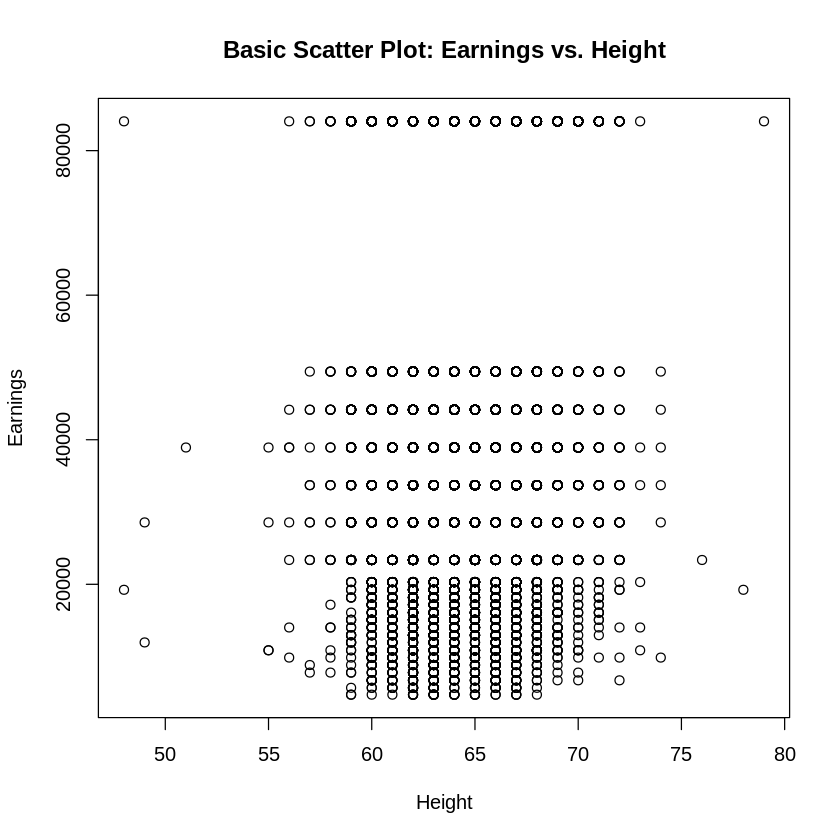

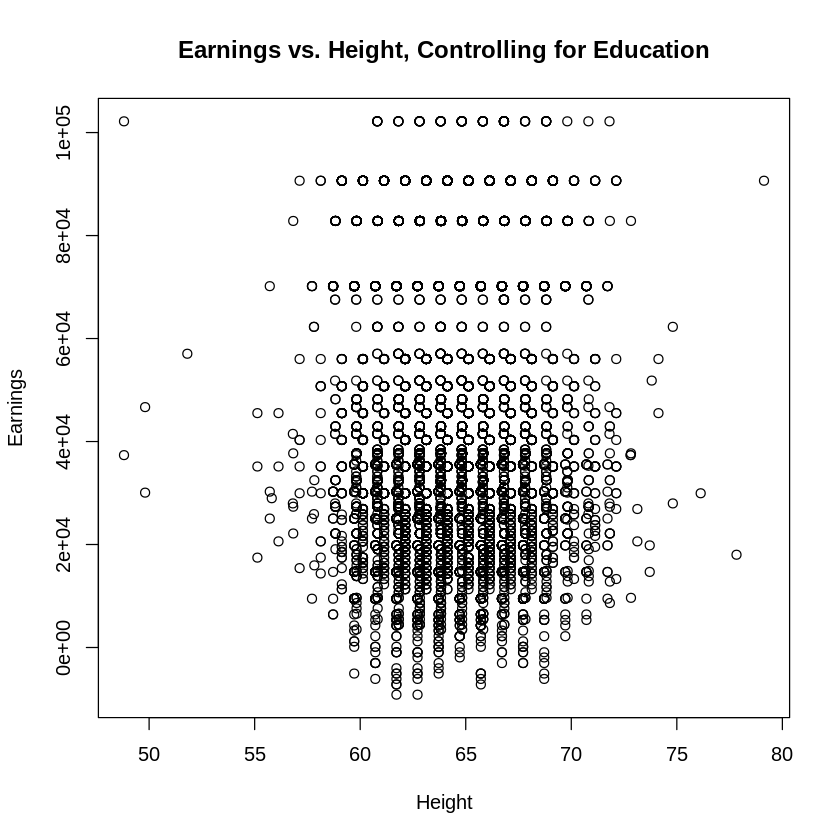

In [ ]:
# xii

plot(df$height[df$sex == 0], df$earnings[df$sex == 0],
     xlab = "Height",
     ylab = "Earnings",
     main = "Basic Scatter Plot: Earnings vs. Height")

X_tilde_ad = X_tilde + mean(df$height[df$sex == 0])
Y_tilde_ad = Y_tilde + mean(df$earnings[df$sex == 0])
plot(X_tilde_ad, Y_tilde_ad,
      xlab = "Height",
      ylab = "Earnings",
      main = "Earnings vs. Height, Controlling for Education")

In [ ]:
# D

model_men = lm(formula = earnings ~ height + lt_hs + hs + some_col, data = filter(df, sex == 1))
summary(model_men)


Call:
lm(formula = earnings ~ height + lt_hs + hs + some_col, data = filter(df, 
    sex == 1))

Residuals:
   Min     1Q Median     3Q    Max 
-58009 -19026  -5227  21320  60912 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   9862.7     6697.0   1.473    0.141    
height         744.7       94.7   7.864 4.22e-15 ***
lt_hs       -31400.5      978.4 -32.092  < 2e-16 ***
hs          -20345.8      692.4 -29.383  < 2e-16 ***
some_col    -12610.9      758.1 -16.636  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 24620 on 7891 degrees of freedom
Multiple R-squared:  0.1658,	Adjusted R-squared:  0.1654 
F-statistic:   392 on 4 and 7891 DF,  p-value: < 2.2e-16
